In [18]:
import pandas as pd
from sklearn.metrics import root_mean_squared_error

In [2]:
schema_nav_df = pd.read_parquet('data/clean/schema_nav.parquet')

In [ ]:
train_set = schema_nav_df[(schema_nav_df['Date'].dt.year >= 2018) & (schema_nav_df['Date'].dt.year <= 2024)]
test_set = schema_nav_df[schema_nav_df['Date'].dt.year > 2024]


In [20]:
test_set = test_set.copy()
test_set['Naive Forecast'] = (test_set['category_avg_nav'].shift(1).fillna(train_set['category_avg_nav'].iloc[-1]))
rmse = root_mean_squared_error(test_set['category_avg_nav'], 
                            test_set['Naive Forecast'])

print("RMSE: ", rmse)

RMSE:  69.20833150054922


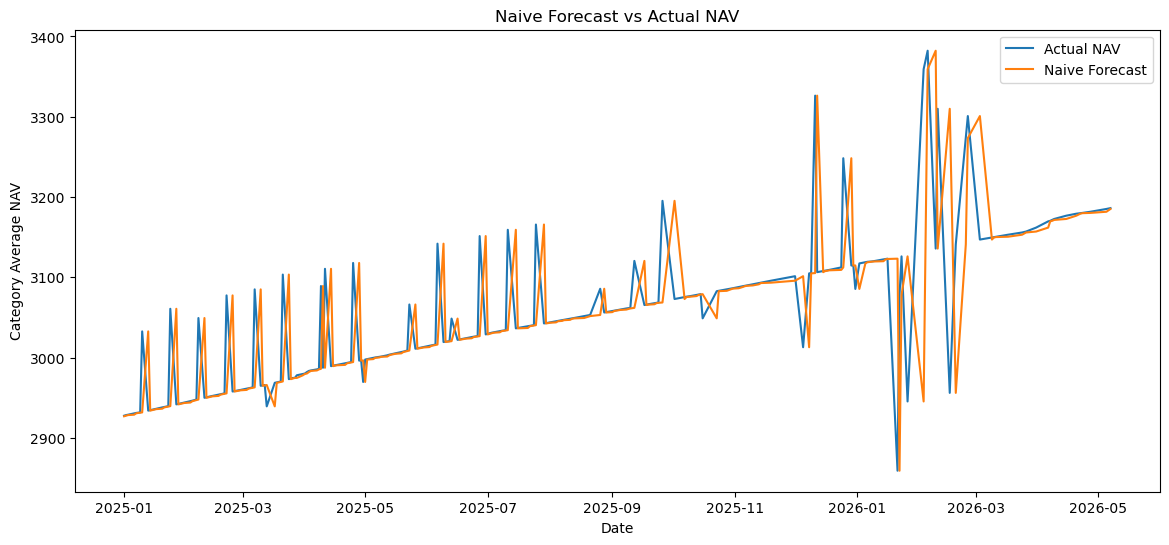

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    test_set['Date'],
    test_set['category_avg_nav'],
    label='Actual NAV'
)

plt.plot(
    test_set['Date'],
    test_set['Naive Forecast'],
    label='Naive Forecast'
)

plt.title('Naive Forecast vs Actual NAV')
plt.xlabel('Date')
plt.ylabel('Category Average NAV')

plt.legend()

plt.show()

In [ ]:

test_
